In [1]:
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import torch
import statsmodels.stats.multitest as multi
import plotly.express as px
from scipy.stats import norm
from scipy import special
import matplotlib.ticker as ticker

In [ ]:
### Load joint probabilities

# Joint probabilities for 1 gene expression
file = open('/path/to/rds/hpc-work/scRNA/model/ll_ones_1000.pt', 'rb')
ll_1 = torch.load(file,map_location=torch.device('cpu')).numpy()
# Joint probability of 0 expresion for all genes
file = open('/path/to/rds/hpc-work/scRNA/model/ll_all_zeros.pt', 'rb')
ll_0 = torch.load(file,map_location=torch.device('cpu')).numpy()
# Joint probability of 2 expresion.
file = open('/path/to/rds/hpc-work/scRNA/model/ll_pairwise_499500.pt', 'rb')
ll_2 = torch.load(file,map_location=torch.device('cpu')).numpy()

ll_2=ll_2.astype('float64')
ll_1=ll_1.astype('float64')
ll_0=ll_0.astype('float64')

# Load the gene-gene combinations
file = open('/path/to/rds/hpc-work/scRNA/model/ss2_pairwise_combo.pickle', 'rb')
MFI_comb = pickle.load(file)
file.close()


In [3]:
MFI=np.zeros(len(MFI_comb))
lv_MFI=np.zeros(len(MFI_comb))
MFI_numer=np.zeros(len(MFI_comb))
MFI_denomi=np.zeros(len(MFI_comb))
sum_cond=np.zeros(len(MFI_comb))
n_cell=15296
lp00=ll_0[0]

In [4]:
def logsumexp(x):
    # Compute the maximum value in the array
    max_value = np.max(x)
    # Subtract the maximum value from all the elements in the array
    shifted_x = x - max_value
    # Compute the sum of the exponentiated shifted values
    sum_exp_shifted = np.sum(np.exp(shifted_x)) 
    # Compute the logsumexp using the identity mentioned in the comments
    log_sum_exp = max_value + np.log(sum_exp_shifted)
    return log_sum_exp

# MFI_comb is stores the gene-gene combinations.  
for i in range(len(MFI_comb)):
    # Pick the log probabilities from the PC output
    lp11=ll_2[i]
    #MFI_comb[i][0] is the index of the first gene.
    lp10=ll_1[MFI_comb[i][0]]
    #MFI_comb[i][1] is the index of the second gene.
    lp01=ll_1[MFI_comb[i][1]]
    
    #Compute the log probability of p(0,0,...,0) after marginalizing out gene1 and gene2 (this line has been validated)
    lp_list=[lp11,lp10,lp01,lp00]
    lMargin=logsumexp(lp_list)

    #Compute the log conditionals (this line has been validated)
    lcp11=lp11-lMargin
    lcp10=lp10-lMargin
    lcp01=lp01-lMargin
    lcp00=lp00-lMargin
    lcondi_list=np.array((lcp11,lcp10,lcp01,lcp00),dtype='float64')
    
    sum_cond[i]=logsumexp(lcondi_list)
    
    #Compute 2-point MFIs (this line has been validated)
    MFI[i]=lp11+lp00-lp01-lp10
    MFI_numer[i]=lp11+lp00
    MFI_denomi[i]=lp01+lp10

    #Compute the log square(standard error of MFI: (this line has been validated)
    lv_MFI[i]=logsumexp(-1*(lcondi_list+np.log(n_cell)))

print('Done')

In [5]:
### log space
z_score=MFI/np.exp(0.5*lv_MFI,dtype='float64')
p_value = (1-stats.norm.cdf(abs(z_score))) * 2

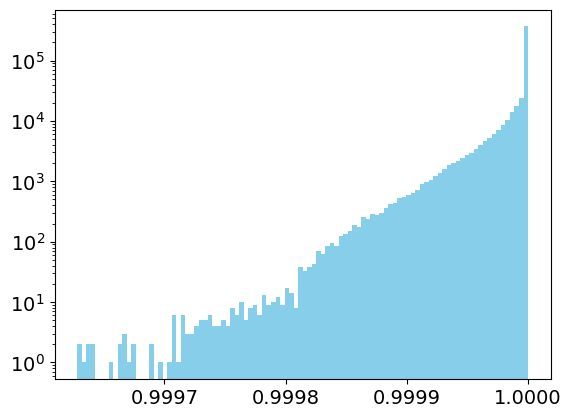

In [6]:
import matplotlib.pyplot as plt
plt.hist(p_value, bins=100,density=False,color='skyblue')  # Adjust the number of bins as needed
#plt.title('2-point MFI p_value')
#plt.ylabel('log Frequency')
plt.title('', fontsize=16, fontweight='bold')
plt.ylabel('', fontsize=16, fontweight='bold')
#plt.xticks(fontsize=10)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))  # Set scientific notation for y-axis
plt.tick_params(axis='x', which='both', labelsize=14) 
plt.grid(False)
plt.show()